# Predicting Water Pump Functionality in Tanzania


## Context

Access to clean water remains one of the most pressing challenges in sub-Saharan Africa. In Tanzania, tens of thousands of water pumps are distributed across the country, but many fall into disrepair without timely maintenance. Predicting which pumps are likely to fail, or have already failed, can help government agencies and NGOs allocate maintenance resources more effectively, reducing downtime and improving water access for vulnerable communities.

This project uses data from the [DrivenData competition "Pump it Up: Data Mining the Water Table"](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/), which provides information on ~59,400 water pumps across Tanzania. The goal is to predict the operational status of each pump as one of three categories:

- **functional** : the pump is operational
- **functional needs repair** : the pump works but needs maintenance
- **non functional** : the pump is not working

## Approach summary

After exploring the data and testing multiple models (Random Forest, Gradient Boosting, Logistic Regression, XGBoost), **Random Forest** consistently outperformed the alternatives. The final pipeline uses correlation-based imputation for missing values and feature selection via Random Forest importance scores. The key insight, and one that shaped the entire iterative process, was that **minimal variable recoding outperformed heavy feature engineering**, a finding that challenged my initial assumptions.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

In [2]:
# Load data
train_values = pd.read_csv('data/TrainingValues.csv')
train_labels = pd.read_csv('data/TrainingLabels.csv')
test_values  = pd.read_csv('data/TestValues.csv')

# Merge training features and labels
train = pd.merge(train_labels, train_values, on='id')

## 3. Exploratory Data Analysis

### 3.1. Target distribution

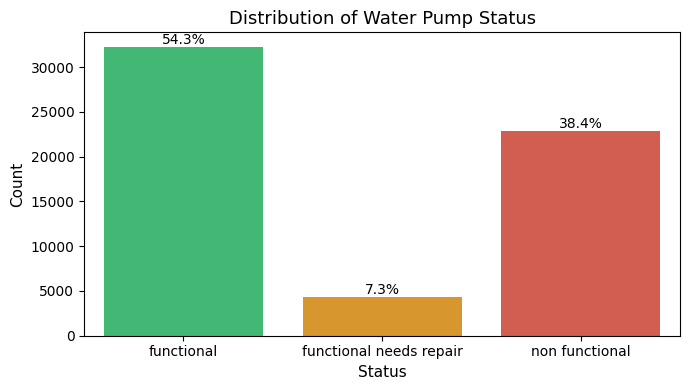

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
order = ['functional', 'functional needs repair', 'non functional']

sns.countplot(data=train, x='status_group', palette=colors, order=order, ax=ax)

ax.set_title('Distribution of Water Pump Status', fontsize=13)
ax.set_xlabel('Status', fontsize=11)
ax.set_ylabel('Count', fontsize=11)

total = len(train)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The dataset is imbalanced: roughly 54% of pumps are functional, 38% non-functional, and only 7% need repair. This imbalance is relevant for model evaluation - accuracy alone may be misleading.

### 3.2. Missing values

In [4]:
# Missing values and suspicious zeros
missing_report = pd.DataFrame({
    'null_count': train.isnull().sum(),
    'null_pct': (train.isnull().sum() / len(train) * 100).round(1)})

# Some variables use 0 as a placeholder for missing data
zero_cols = ['amount_tsh', 'gps_height', 'longitude', 'population', 'construction_year']
for col in zero_cols:
    zero_pct = (train[col] == 0).sum() / len(train) * 100
    missing_report.loc[col, 'zero_as_null_pct'] = round(zero_pct, 1)

missing_report[missing_report[['null_pct', 'zero_as_null_pct']].max(axis=1) > 0].sort_values(
    by=['null_pct', 'zero_as_null_pct'], ascending=False)

,null_count,null_pct,zero_as_null_pct
scheme_name,28810,48.5,NaN
scheme_management,3878,6.5,NaN
installer,3655,6.2,NaN
funder,3637,6.1,NaN
public_meeting,3334,5.6,NaN
permit,3056,5.1,NaN
subvillage,371,0.6,NaN
amount_tsh,0,0.0,70.1
population,0,0.0,36.0
construction_year,0,0.0,34.9


### 3.3. Redundant variable groups

Several variable groups represent the same underlying concept at different granularity levels. To decide which one to keep, I compared their association with the target using chi-squared tests.

In [5]:
redundant_groups = [
    ['extraction_type', 'extraction_type_group', 'extraction_type_class'],
    ['management', 'management_group'],
    ['payment', 'payment_type'],
    ['water_quality', 'quality_group'],
    ['quantity', 'quantity_group'],
    ['source', 'source_type', 'source_class'],
    ['waterpoint_type', 'waterpoint_type_group']]

print(f'{"Variable":<30} {"Chi²":>12} {"p-value":>12}')
print('-' * 56)
for group in redundant_groups:
    for var in group:
        table = pd.crosstab(train[var], train['status_group'])
        chi2, p, dof, expected = chi2_contingency(table)
        marker = ' ◄' if chi2 == max(
            chi2_contingency(pd.crosstab(train[v], train['status_group']))[0] for v in group
        ) else ''
        print(f'{var:<30} {chi2:>12,.0f} {p:>12.4f}{marker}')
    print()

Variable                               Chi²      p-value
--------------------------------------------------------
extraction_type                       7,366       0.0000 ◄
extraction_type_group                 7,266       0.0000
extraction_type_class                 6,931       0.0000

management                            2,081       0.0000 ◄
management_group                        288       0.0000

payment                               3,966       0.0000
payment_type                          3,966       0.0000 ◄

water_quality                         2,277       0.0000 ◄
quality_group                         2,100       0.0000

quantity                             11,361       0.0000 ◄
quantity_group                       11,361       0.0000 ◄

source                                2,624       0.0000 ◄
source_type                           1,907       0.0000
source_class                            590       0.0000

waterpoint_type                       7,450       0.0000 ◄
waterpoin

The variable with the highest chi² in each group (marked with ◄) carries the most information about pump status. However, as I discovered later in the modeling phase, **keeping all variables without manual recoding actually produced better results** than dropping redundant ones. The Random Forest handles multicollinearity implicitly by distributing importance across correlated features.

### 3.4. Variable-level observations

After reviewing each variable individually, these were the key observations that informed preprocessing:

- **amount_tsh**: 70% of values are 0 (no water). Better treated as a binary indicator (has water / no water).
- **date_recorded**: Ranges from 2002 to 2013. Converted to months elapsed for numerical comparability.
- **funder / installer**: 1,896 and 2,145 unique values respectively. Low-frequency categories grouped as 'Other'.
- **gps_height**: Many zeros and negatives, treated as missing and imputed using regional means.
- **population**: 25% zeros, imputed using regional medians.
- **construction_year**: ~35% zeros, imputed using regional means.
- **scheme_name**: ~50% missing, retained for the model to assess importance rather than dropped preemptively.
- **recorded_by**: Single unique value, carries no predictive information.
- **num_private**: Mostly zeros, appears to be an ID field — no predictive value.
- **region_code**: Some inconsistencies between region names and codes, corrected manually.

## 4. Feature Engineering & Preprocessing

Based on the EDA findings, I apply transformations to both training and test sets simultaneously to ensure consistency.

### 4.1. General transformations

In [6]:
def preprocess_general(df):
    """Apply general transformations to training or test data."""
    df = df.copy()

    # Binary indicator: has water or not
    df['amount_tsh'] = (df['amount_tsh'] != 0).astype(int)

    # Date to months elapsed (reference: April 2025)
    ref_date = datetime(2025, 4, 1)
    df['date_recorded'] = pd.to_datetime(df['date_recorded'])
    df['date_recorded'] = df['date_recorded'].apply(
        lambda x: (ref_date.year - x.year) * 12 + (ref_date.month - x.month))

    # Treat invalid zeros as NaN
    df['gps_height'] = df['gps_height'].apply(lambda x: np.nan if x <= 0 else x)
    df['population'] = df['population'].apply(lambda x: np.nan if x <= 0 else x)
    df['longitude']  = df['longitude'].apply(lambda x: np.nan if x == 0 else x)

    return df


train = preprocess_general(train)
test_values = preprocess_general(test_values)

### 4.2. Fix geolocation outlier

One data point (ID 49651) had coordinates placing it outside Tanzania. Its latitude and longitude were imputed using the mean for its region (Shinyanga).

In [7]:
lat_shinyanga = train[train['region'] == 'Shinyanga']['latitude'].mean()
lon_shinyanga = train[train['region'] == 'Shinyanga']['longitude'].mean()

train.loc[train['id'] == 49651, 'latitude'] = lat_shinyanga
train.loc[train['id'] == 49651, 'longitude'] = lon_shinyanga

print(f'Outlier corrected: lat={lat_shinyanga:.4f}, lon={lon_shinyanga:.4f}')

Outlier corrected: lat=-2.7905, lon=33.2401


### 4.3. Fix region code inconsistencies

Some region codes did not match their region names. These were corrected manually based on the dominant mapping in the data.

In [8]:
region_code_map = {
    'Dodoma': 1, 'Arusha': 2, 'Kilimanjaro': 3, 'Tanga': 4, 'Morogoro': 5,
    'Pwani': 6, 'Dar es Salaam': 7, 'Lindi': 8, 'Mtwara': 9, 'Ruvuma': 10,
    'Iringa': 11, 'Mbeya': 12, 'Singida': 13, 'Tabora': 14, 'Rukwa': 15,
    'Kigoma': 16, 'Shinyanga': 17, 'Kagera': 18, 'Mwanza': 19, 'Mara': 20,
    'Manyara ': 21, 'Manyara': 21}

for region, code in region_code_map.items():
    train.loc[train['region'] == region, 'region_code'] = code
    test_values.loc[test_values['region'] == region, 'region_code'] = code

### 4.4. Correlation-based imputation

Rather than imputing all missing values with global medians or modes, I imputed each variable using the most correlated available variable as a grouping key. For example, `funder` was imputed using the mode within each `installer` group, and `gps_height` was imputed using the median within each `longitude` group.

This approach preserves local patterns in the data and produced better model performance than global imputation.

In [9]:
def impute_by_group(df, target_col, group_col, strategy='mode'):
    """Impute missing values in target_col using the mode or median within group_col."""
    if strategy == 'mode':
        df[target_col] = df.groupby(group_col)[target_col].transform(
            lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
    elif strategy == 'median':
        df[target_col] = df.groupby(group_col)[target_col].transform(
            lambda x: x.fillna(x.median()) if pd.api.types.is_numeric_dtype(x) and not x.dropna().empty else x)
    return df


# Define imputation pairs: (target_column, group_column, strategy)
imputation_rules = [
    ('funder','installer','mode'),
    ('installer','funder','mode'),
    ('gps_height','longitude','median'),
    ('longitude','region_code','median'),
    ('population','region_code','median'),
    ('wpt_name','date_recorded','mode'),
    ('subvillage','wpt_name','mode'),
    ('public_meeting','payment','mode'),
    ('scheme_management','management','mode'),
    ('scheme_name','waterpoint_type','mode'),
    ('permit','installer','mode')]

for target, group, strategy in imputation_rules:
    train = impute_by_group(train, target, group, strategy)
    test_values = impute_by_group(test_values, target, group, strategy)

print('Correlation-based imputation complete.')
print(f'Remaining nulls in train: {train.isnull().sum().sum()}')
print(f'Remaining nulls in test:  {test_values.isnull().sum().sum()}')

Correlation-based imputation complete.
Remaining nulls in train: 45312
Remaining nulls in test:  11383


## 5. Model Training

### 5.1. Model comparison

Before arriving at the final model, I tested four classifiers on the same preprocessed data. Results (accuracy via cross-validation):

| Model | Accuracy |
|---|---|
| Random Forest | **Best** |
| Gradient Boosting | Good, slower training |
| XGBoost | Comparable to GB |
| Logistic Regression | Lowest performance |

Random Forest was selected as the final model for its consistent top performance and reasonable training time.

### 5.2. Feature selection via Random Forest importance

An initial Random Forest was trained on all variables to extract feature importances. Features were then grouped by their original variable name (since one-hot encoding creates multiple columns per categorical variable), and variables with non-zero aggregated importance were retained.

In [10]:
# Prepare data for feature selection
X_train_fs = train.drop(columns=['status_group'])
y_train_fs = train['status_group']

cat_cols_fs = X_train_fs.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols_fs = X_train_fs.select_dtypes(include=['number']).columns.tolist()

# Fill any remaining nulls for the feature selection pass
for col in X_train_fs.columns:
    if X_train_fs[col].dtype in ['float64', 'int64']:
        X_train_fs[col] = X_train_fs[col].fillna(X_train_fs[col].median())
    elif X_train_fs[col].dtype == 'object':
        X_train_fs[col] = X_train_fs[col].fillna(X_train_fs[col].mode()[0])

preprocessor_fs = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_fs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_fs)],
    remainder='passthrough')

pipeline_fs = Pipeline(steps=[
    ('preprocessor', preprocessor_fs),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

pipeline_fs.fit(X_train_fs, y_train_fs)

# Extract and aggregate feature importances
importances = pipeline_fs.named_steps['classifier'].feature_importances_
onehot_cols = preprocessor_fs.named_transformers_['cat'].get_feature_names_out(cat_cols_fs)
all_features = num_cols_fs + list(onehot_cols)

fi = pd.DataFrame({'feature': all_features, 'importance': importances})
fi['original'] = fi['feature'].apply(lambda x: x.split('_')[0] if '_' in x else x)
grouped_fi = fi.groupby('original')['importance'].sum().sort_values(ascending=False)

print('Feature importances (aggregated by original variable):\n')
print(grouped_fi.to_string())

Feature importances (aggregated by original variable):

original
wpt             0.124974
subvillage      0.111801
quantity        0.086420
ward            0.068940
extraction      0.057790
scheme          0.056705
funder          0.042932
installer       0.039632
latitude        0.039439
longitude       0.039253
waterpoint      0.038465
payment         0.035134
lga             0.032737
id              0.031917
gps             0.024764
source          0.024699
region          0.024548
population      0.019650
construction    0.017939
management      0.016262
basin           0.013707
date            0.010071
water           0.008566
quality         0.007881
district        0.007605
amount          0.006213
permit          0.005834
public          0.005508
num             0.000613
recorded        0.000000


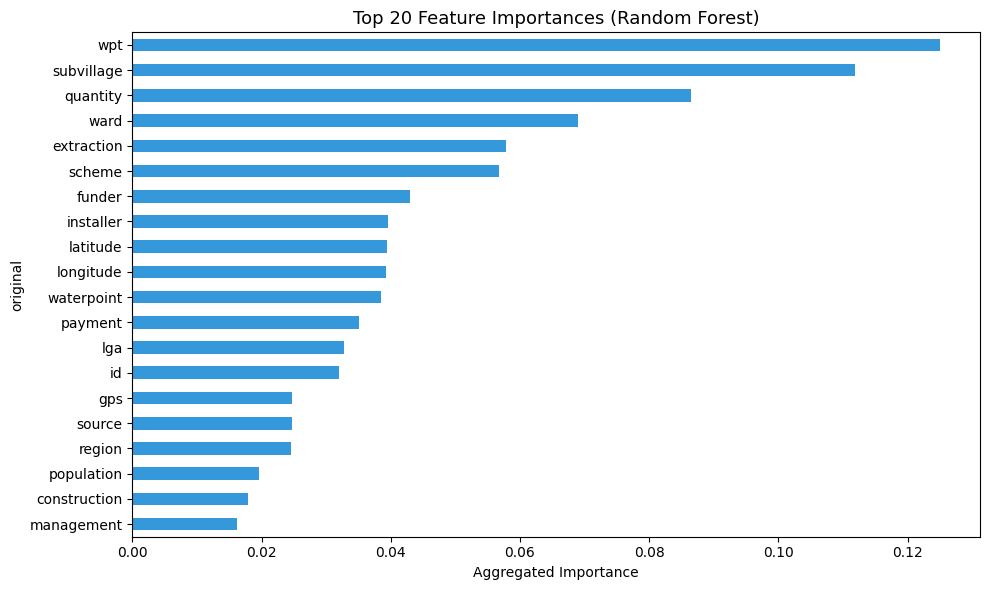

In [11]:
# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
grouped_fi.head(20).plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Aggregated Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3. Final model: selected features + Random Forest

In [12]:
# Selected features based on importance analysis
selected_features = [
    'wpt_name', 'subvillage', 'ward', 'scheme_name', 'quantity_group', 'quantity','funder', 'installer',
    'latitude', 'longitude', 'lga', 'gps_height','waterpoint_type', 'extraction_type',
    'extraction_type_group', 'population','construction_year', 'region', 'payment_type', 'payment',
    'extraction_type_class', 'waterpoint_type_group', 'basin', 'source', 'management', 'scheme_management',
    'date_recorded']

X_train = train[selected_features].copy()
y_train = train['status_group']
X_test  = test_values[selected_features].copy()

# Define feature types for the pipeline
numerical_features = ['latitude', 'longitude', 'gps_height', 'construction_year', 'date_recorded']
categorical_features = [f for f in selected_features if f not in numerical_features]

print(f'Selected features: {len(selected_features)}')
print(f'  Numerical:   {len(numerical_features)}')
print(f'  Categorical: {len(categorical_features)}')

Selected features: 27
  Numerical:   5
  Categorical: 22


In [13]:
# Build final pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())]),
     numerical_features),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))]),
     categorical_features)])

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

# Train
final_pipeline.fit(X_train, y_train)

# Training accuracy (in-sample, for reference)
train_accuracy = final_pipeline.score(X_train, y_train)
print(f'Training accuracy: {train_accuracy:.4f}')

Training accuracy: 1.0000


### 5.4. Generate predictions

In [14]:
y_pred = final_pipeline.predict(X_test)

submission = pd.DataFrame({
    'id': test_values['id'],
    'status_group': y_pred})

print(f'Predictions generated: {len(submission):,} rows')
print(f'\nPredicted distribution:')
print(submission['status_group'].value_counts(normalize=True).round(3))

# Save predictions
submission.to_csv('predictions.csv', index=False)
print('\nSaved to predictions.csv')

Predictions generated: 14,850 rows

Predicted distribution:
status_group
functional                 0.604
non functional             0.358
functional needs repair    0.038
Name: proportion, dtype: float64

Saved to predictions.csv


## 6. Results & Reflections

### What worked

The best-performing model was **Random Forest** with:
- Correlation-based imputation (imputing each variable using the most related variable as a grouping key)
- Feature selection via RF importance (27 features retained from the original 40)
- **No manual variable recoding** : using the raw categorical variables as-is

### What did not work

- **Dropping rows or columns with nulls** reduced performance significantly.
- **Heavy feature engineering** (recoding categoricals into binary indicators, grouping high-cardinality variables, dropping redundant columns based on chi² tests) consistently performed *worse* than letting the model handle the raw variables. This was the most counterintuitive finding.
- **Logistic Regression** performed poorly, likely due to the high-cardinality categorical features and non-linear relationships in the data.

### The key lesson: intuition vs. data

I called Attempt 12 "the frustration attempt" because I essentially stripped out most of the preprocessing I had spent hours building: the chi²-based variable selection, the binary recodings, the careful grouping of categories. I submitted the raw variables with only basic imputation, expecting worse results. Instead, **it was the best score so far**.

This was a turning point. It forced me to accept that my statistical intuition, that reducing multicollinearity and simplifying categories should help, was not serving this particular problem. The Random Forest was already handling these issues internally through its ensemble structure. From that point on, I focused on what *did* matter: the quality of imputation and ensuring consistency between training and test preprocessing.

### What I would do differently

- **Start with the simplest model first** and only add complexity when motivated by results, rather than front-loading feature engineering based on assumptions.
- **Ensure train/test preprocessing consistency from the start.** In some early attempts, I applied different imputation strategies to each set, which introduced subtle data leakage.
- **Invest more time in understanding the domain.** Knowing which variables truly matter for water pump maintenance in Tanzania, such as the age of the pump, the funding source, and the management structure, would have guided preprocessing decisions more effectively than purely statistical criteria.

### Broader relevance

This kind of predictive model has direct applications in social impact work: enabling governments and NGOs to prioritize maintenance visits to pumps most likely to fail, reducing water access interruptions for communities that depend on them. The same methodology, classification of infrastructure condition using administrative and geographic data, could be applied to other development contexts: school facilities, health clinics, sanitation systems.